In [2]:

%load_ext autoreload
%autoreload 2

import os, sys, pathlib

ROOT = pathlib.Path.cwd()
while not (ROOT / 'crossmatching').exists():
    ROOT = ROOT.parent
os.chdir(ROOT)

import numpy as np
from astropy.table import Table, Column
from astropy import units as u
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import display, HTML
from crossmatching import Crossmatcher, EMCCatalog, EMCIdSupplier, NEACatalog, SimbadIdSupplier, ParamFiller, temperate_mask, rocky_mask
from crossmatching.enrichment import (
    HpicParamSource, NeaParamSource, SimbadParamSource,
    EpicParamSource, ToiParamSource, EuParamSource
)
from crossmatching import allowed_angular_separation
from crossmatching.enrichment import classify_spectral_type
import astropy
import astroquery.simbad
import numpy as np
from astropy.table import Table
from astropy.io import ascii
import astropy.units as u
from astropy.coordinates import SkyCoord
import pyarrow
import pyvo
from astroquery.simbad import Simbad
from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive
from collections import Counter
import timeit
import matplotlib.pyplot as plt
import pandas
import os
import numpy.ma as ma
import plotly.graph_objects as go

mpl.rcParams['figure.dpi'] = 300


In [5]:
cm = Crossmatcher(NEACatalog(), SimbadIdSupplier())
cm.load_catalog(from_file="./input/pscomppars.txt")
input_t = ascii.read("./input/HPIC_LC4_combined_d50.txt")
name_list = input_t["star_name"]  
_ = cm.load_alternate_ids(name_list, from_file="./input/alternate_ids_hpic.txt")

matched = cm.combined_crossmatch(input_t, "star_name")
id_matched = matched[matched["match_type"]!= 'coordinates']
id_matched = cm.remove_duplicates(id_matched, "star_name", from_file="./input/alternate_ids_hpic.txt")
id_matched.sort("crossmatching_angular_separation")

In [6]:
id_matched["expected_sep"] = allowed_angular_separation(
    proper_motion=id_matched["sy_pm"]*NEACatalog().pm_unit.to(u.arcsec/u.yr),
    pm_err=id_matched["sy_pmerr1"]*NEACatalog().pm_unit.to(u.arcsec/u.yr),
    epoch=id_matched["coord_epoch"],
    input_epoch=2000,
    minimum = 0 * u.arcsec,
    unknown_default=0 * u.arcsec,
)

id_matched["allowed_sep"] = allowed_angular_separation(
    proper_motion=id_matched["sy_pm"]*NEACatalog().pm_unit.to(u.arcsec/u.yr),
    pm_err=id_matched["sy_pmerr1"]*NEACatalog().pm_unit.to(u.arcsec/u.yr),
    epoch=id_matched["coord_epoch"],
    input_epoch=2000,
    unknown_default=np.nan * u.arcsec
)

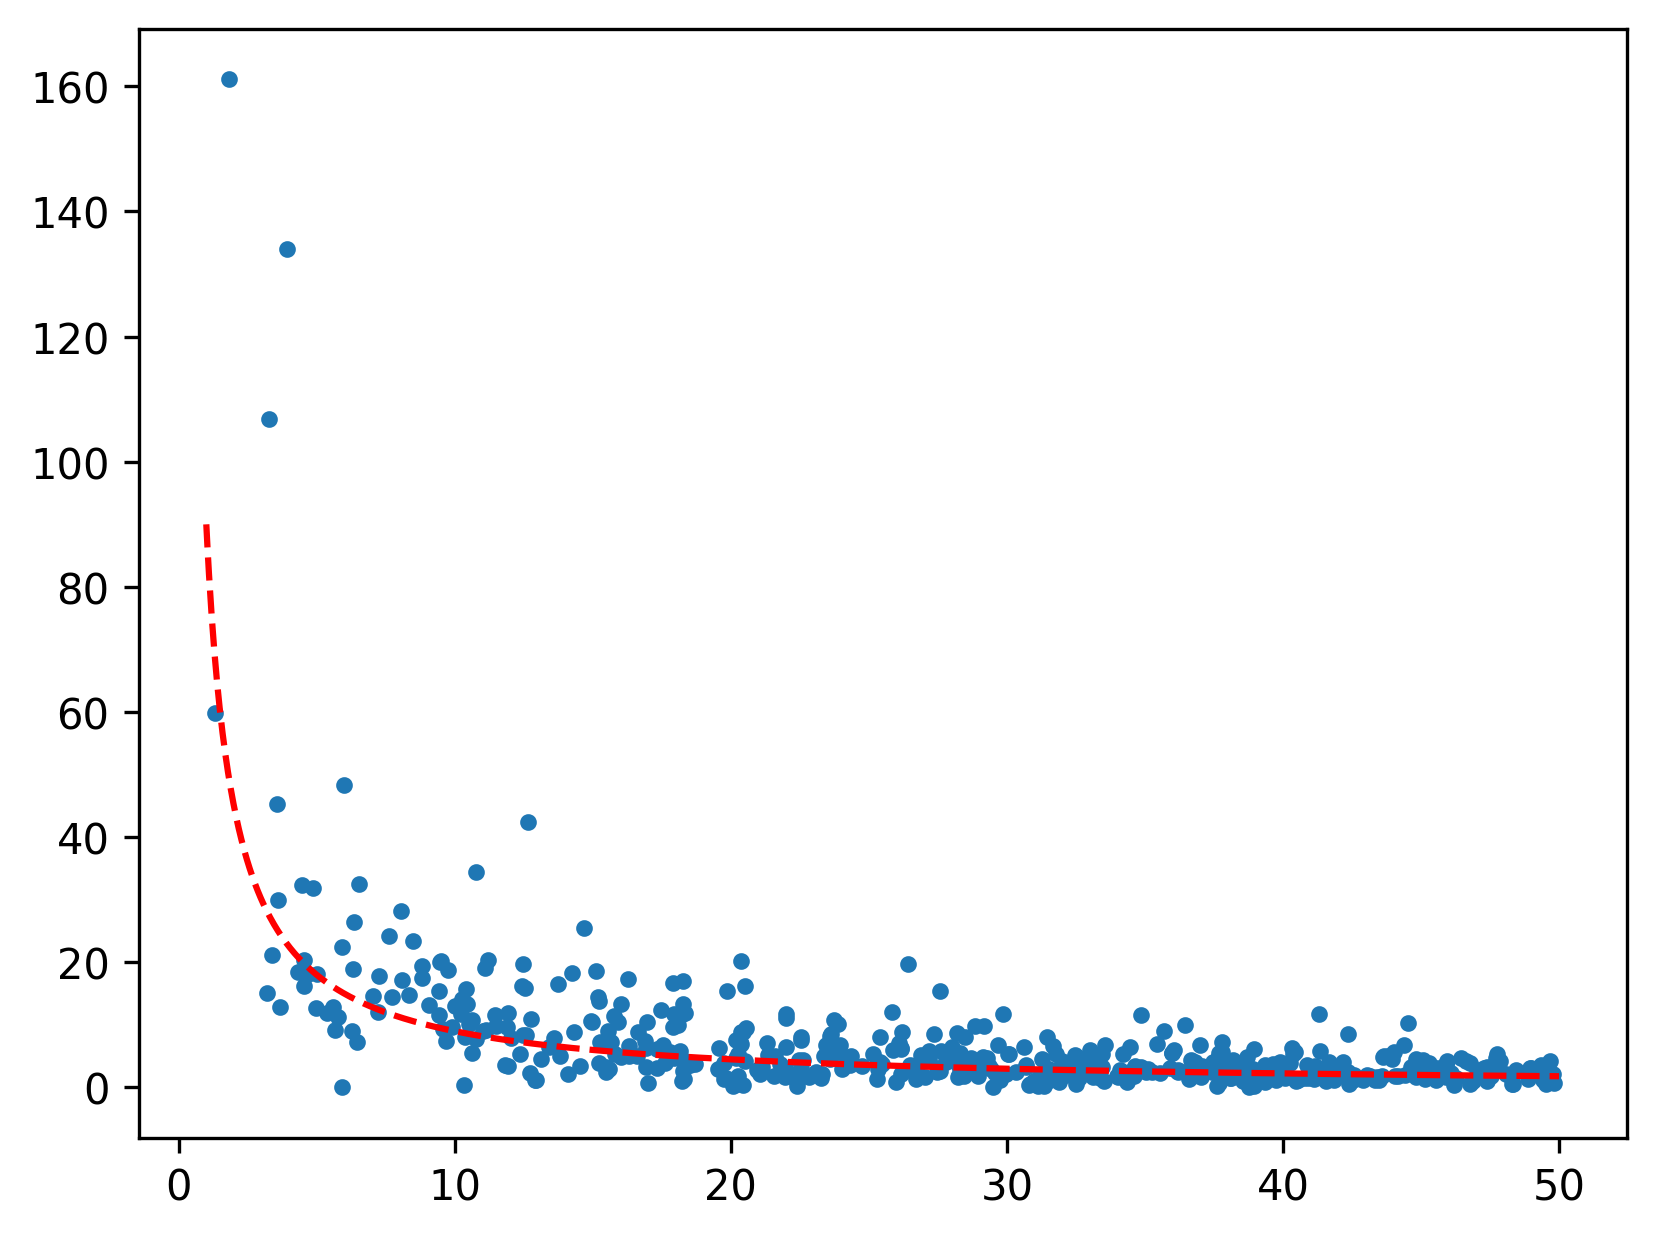

In [7]:
plt.plot(id_matched["sy_dist"], id_matched["crossmatching_angular_separation"], ".")
dist_axis = np.linspace(1, 50, 1000)
plt.plot(dist_axis, 90/dist_axis, "r--")

In [8]:
id_matched["crossmatching_angular_separation"]
id_matched["expected_sep"]

0.0
0.0
0.0
0.24295721600000006
0.26232877600000004
0.2637096976000001
0.2653753568
0.2661963552
0.3022908096000001
0.4431505360000001
0.0


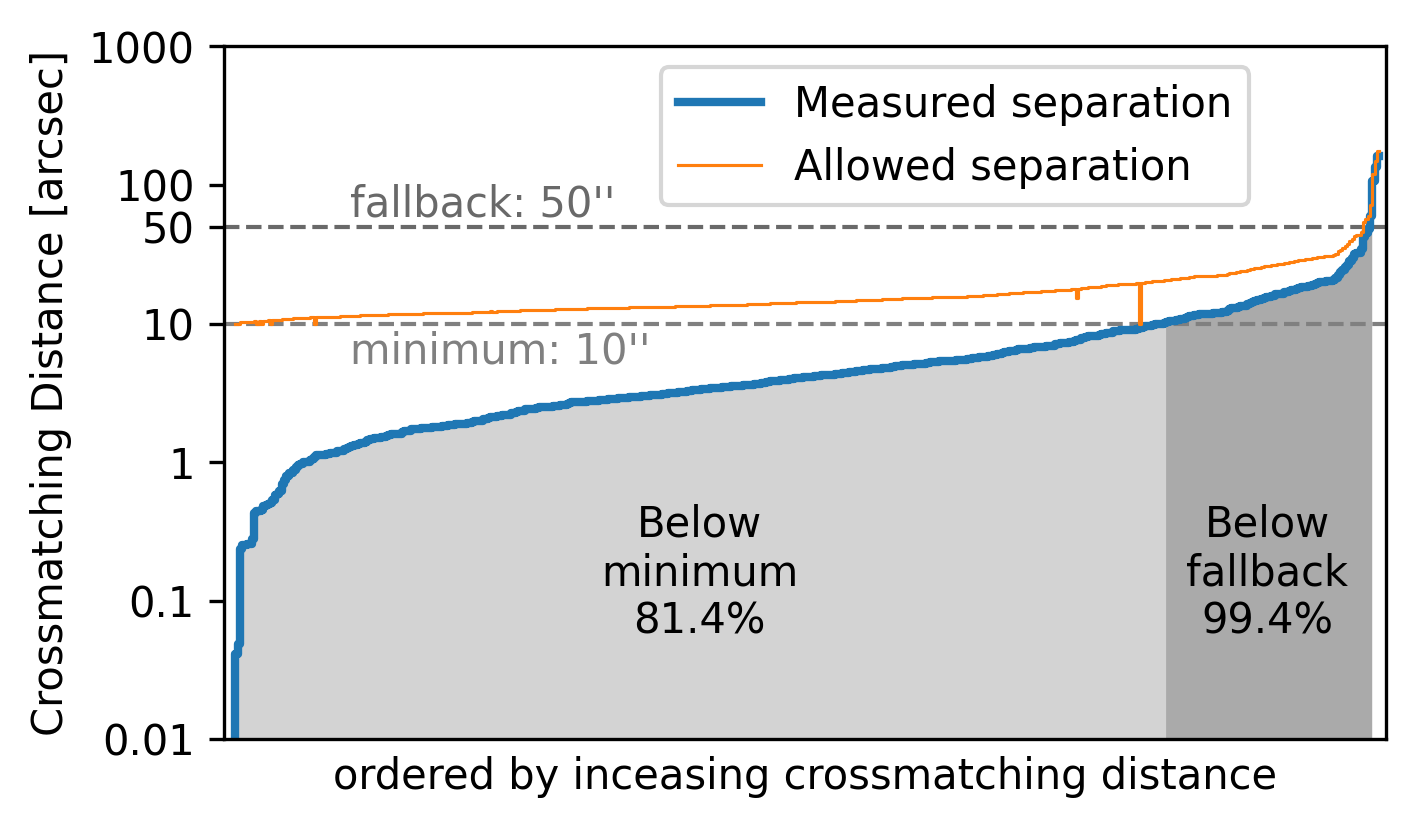

In [10]:
x = list(range(len(id_matched)))
id_matched.sort("crossmatching_angular_separation")

# fig, ax = plt.subplots(figsize=(7, 4))
fig, ax = plt.subplots(figsize=(5, 3))
ax.axhline(50, color="dimgray", ls="--", lw=1)
ax.axhline(10, color="gray", ls="--", lw=1)
ax.set_yscale("log")

from matplotlib.ticker import FixedFormatter, FixedLocator

ax.set_ylim(0.01, 1000)
tick_values = [1E-2, 1E-1, 1, 10, 50, 100, 1000]
ax.yaxis.minorticks_off()
ax.yaxis.set_major_locator(FixedLocator(tick_values))
ax.yaxis.set_major_formatter(FixedFormatter([f"{i}" for i in tick_values]))
ax.xaxis.set_major_formatter(FixedFormatter([]))
plt.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)

measured_vals = np.asarray(id_matched["crossmatching_angular_separation"])


index_below_default = np.argmin(id_matched["crossmatching_angular_separation"] < 50 * u.arcsec)
index_below_minimum = np.argmin(id_matched["crossmatching_angular_separation"] < 10 * u.arcsec)

x_fill_default = x[:index_below_default]
y_fill_default = measured_vals[:index_below_default]
x_fill_min = x[:index_below_minimum]
y_fill_min = measured_vals[:index_below_minimum]

ax.fill_between(x_fill_default, y_fill_default, y2=0, step="mid", color="#aaaaaa")
ax.text(
    (x_fill_min[-1] + x_fill_default[-1]) /2,
    0.05,
    f"Below\nfallback\n{(index_below_default+1)/len(id_matched)*100:.1f}%",
    ha="center",
    va="bottom",
    fontsize=10,
)

ax.fill_between(x_fill_min, y_fill_min, y2=0, step="mid", color="lightgray")
ax.text(
    (x_fill_min[0] + x_fill_min[-1]) / 2,
    0.05,
    f"Below\nminimum\n{(index_below_minimum+1)/len(id_matched)*100:.1f}%",
    ha="center",
    va="bottom",
    fontsize=10,
)

ax.step(x, id_matched["crossmatching_angular_separation"], where="pre", label="Measured separation", lw=2)
ax.step(x, id_matched["allowed_sep"], where="pre", label="Allowed separation", lw=0.75)

ax.text(len(id_matched)*0.1, 10 -1 , "minimum: 10''", ha="left", va="top", color="gray")
ax.text(len(id_matched)*0.1, 50 +1 , "fallback: 50''", ha="left", va="bottom", color="dimgray")

ax.set_xlim(-5,len(id_matched) + 2)
ax.set_ylabel("Crossmatching Distance [arcsec]")
ax.set_xlabel("ordered by inceasing crossmatching distance")
ax.legend(loc="upper right", bbox_to_anchor=(0.9,1))

plt.savefig("./notebooks/plots/nea_coord_calibration.pdf", bbox_inches="tight", dpi=300)

np.int64(0)

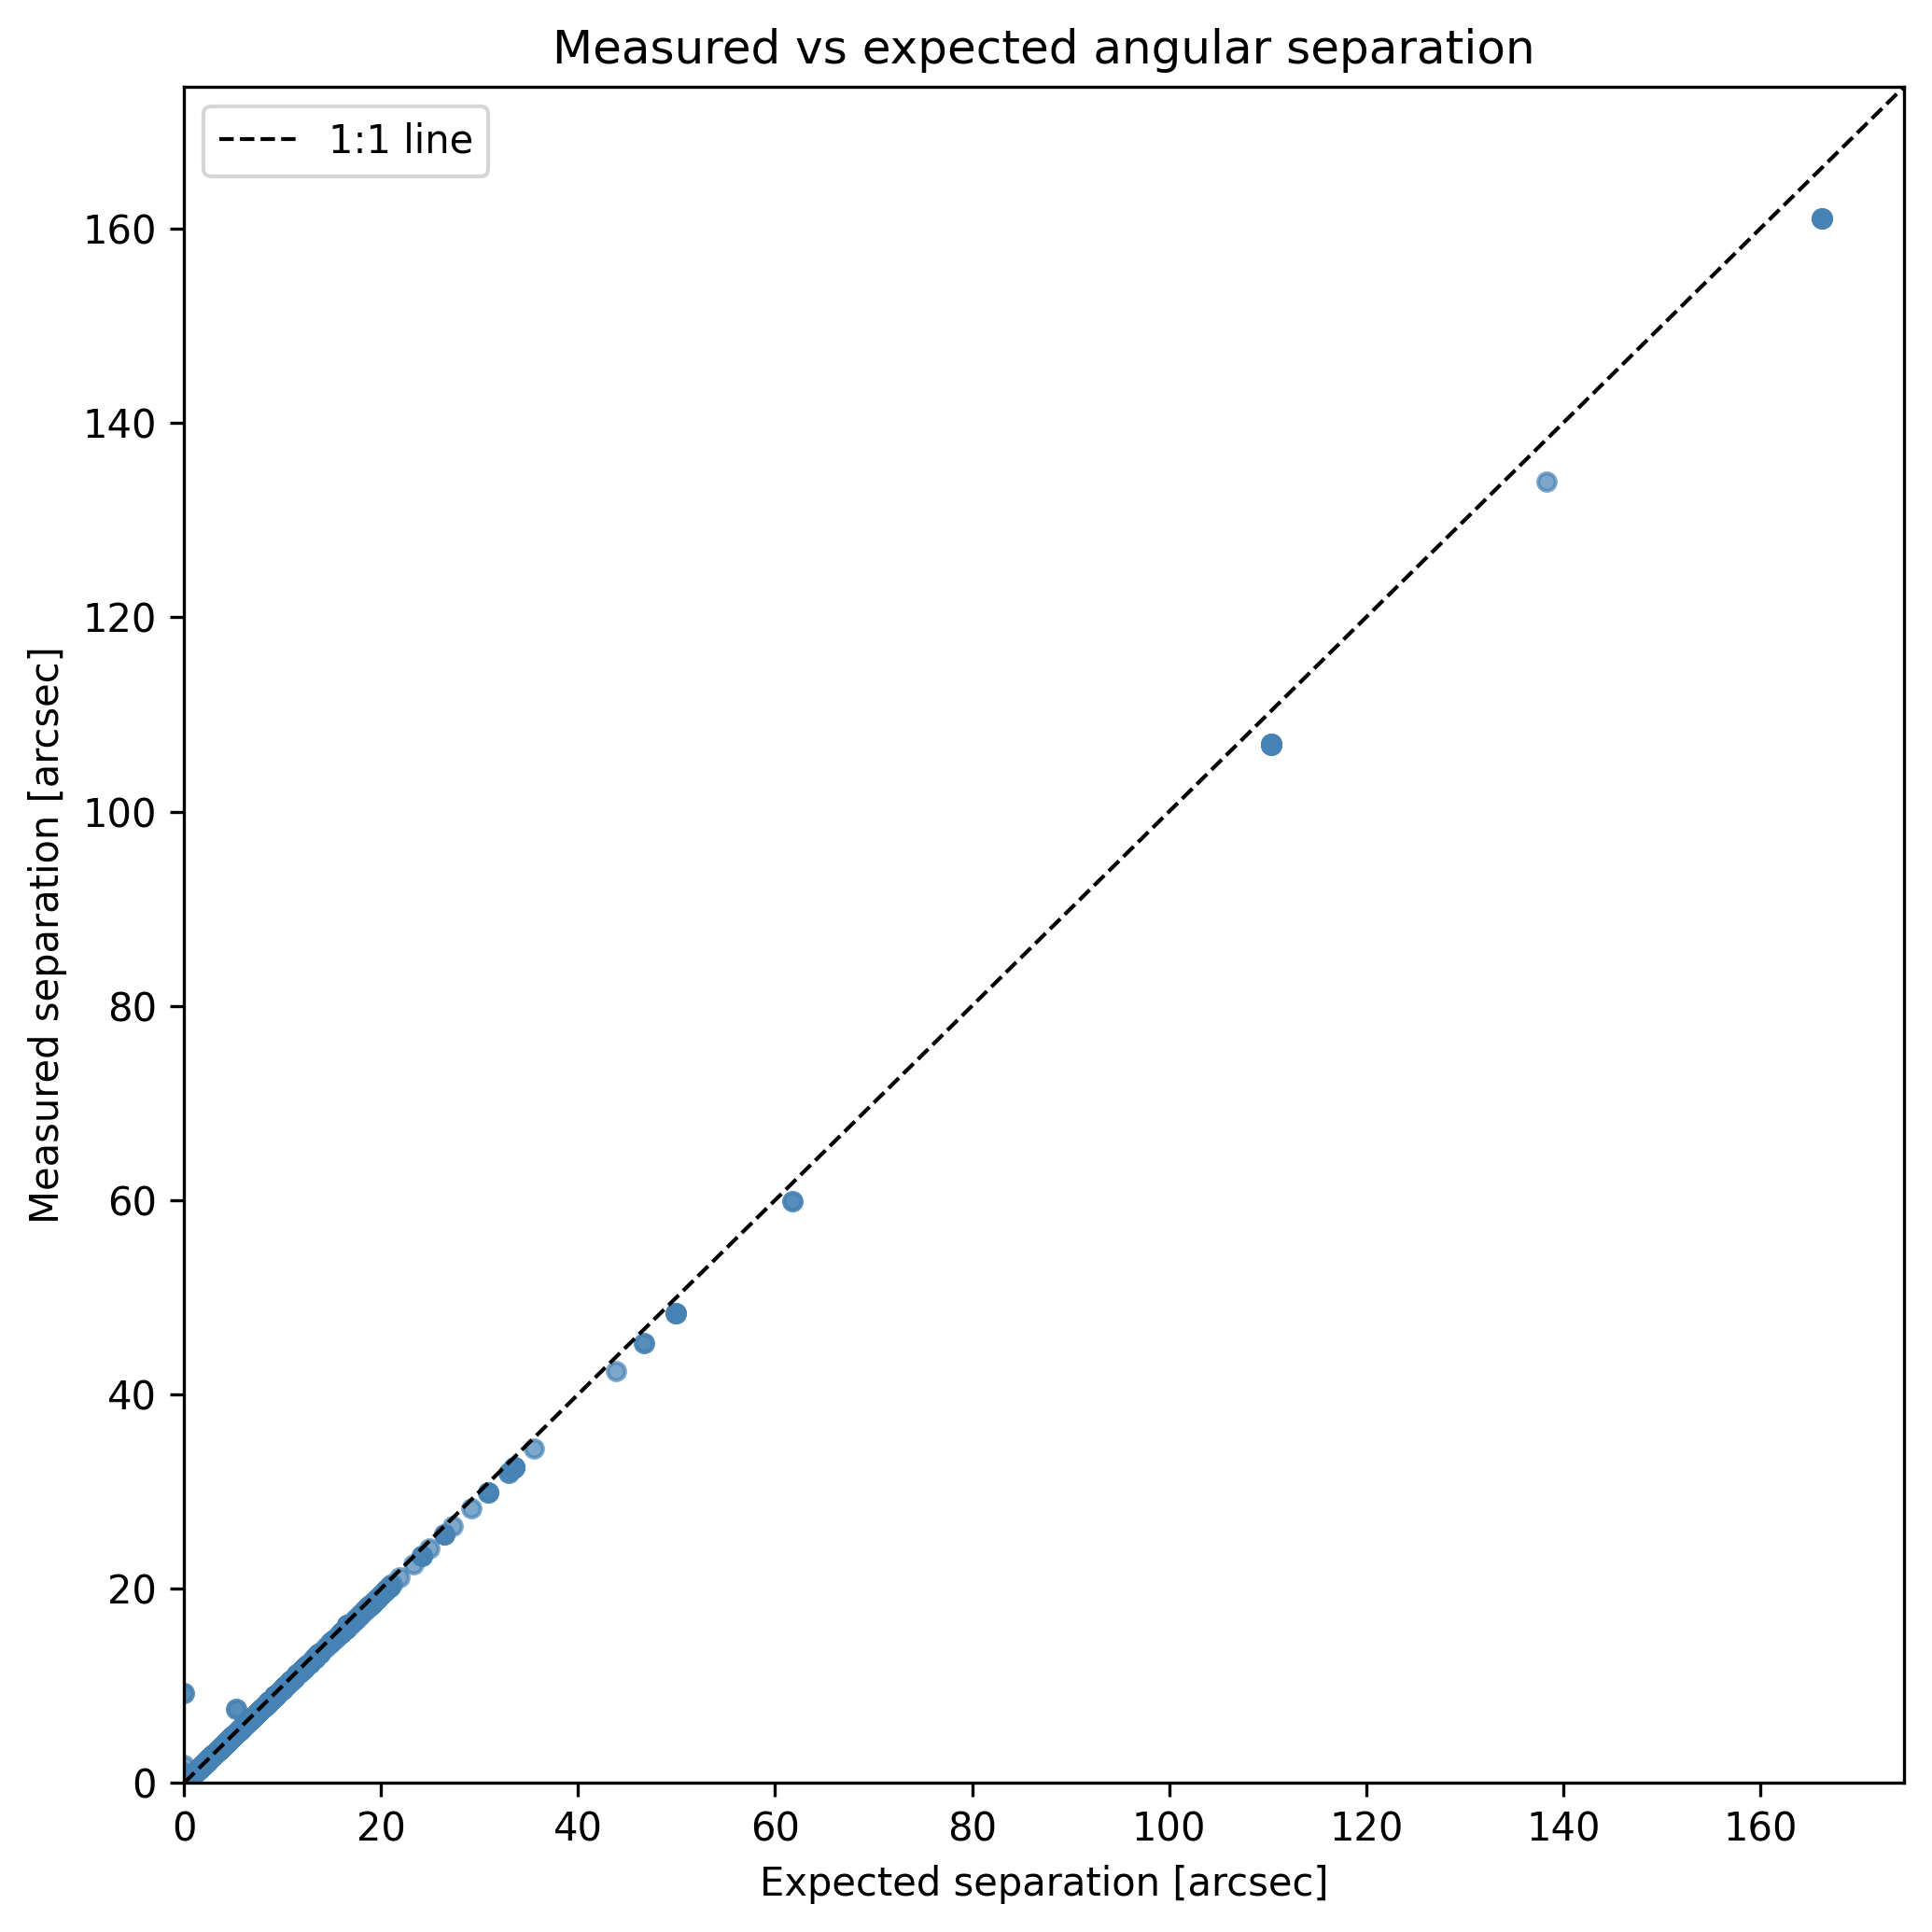

In [ ]:
measured = np.asarray(id_matched["crossmatching_angular_separation"])
expected = np.asarray(id_matched["expected_sep"])

if hasattr(measured, "unit"):
    measured = measured.to_value(u.arcsec)
if hasattr(expected, "unit"):
    expected = expected.to_value(u.arcsec)

valid = np.isfinite(measured) & np.isfinite(expected)
measured = measured[valid]
expected = expected[valid]

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(expected, measured, s=20, alpha=0.7, color="steelblue")

lims = [0, max(np.nanmax(expected), np.nanmax(measured)) * 1.05]
ax.plot(lims, lims, "k--", lw=1, label="1:1 line")
ax.set_xlim(lims)
ax.set_ylim(lims)


ax.set_xlabel("Expected separation [arcsec]")
ax.set_ylabel("Measured separation [arcsec]")
ax.set_title("Measured vs expected angular separation")
ax.legend()
plt.tight_layout()

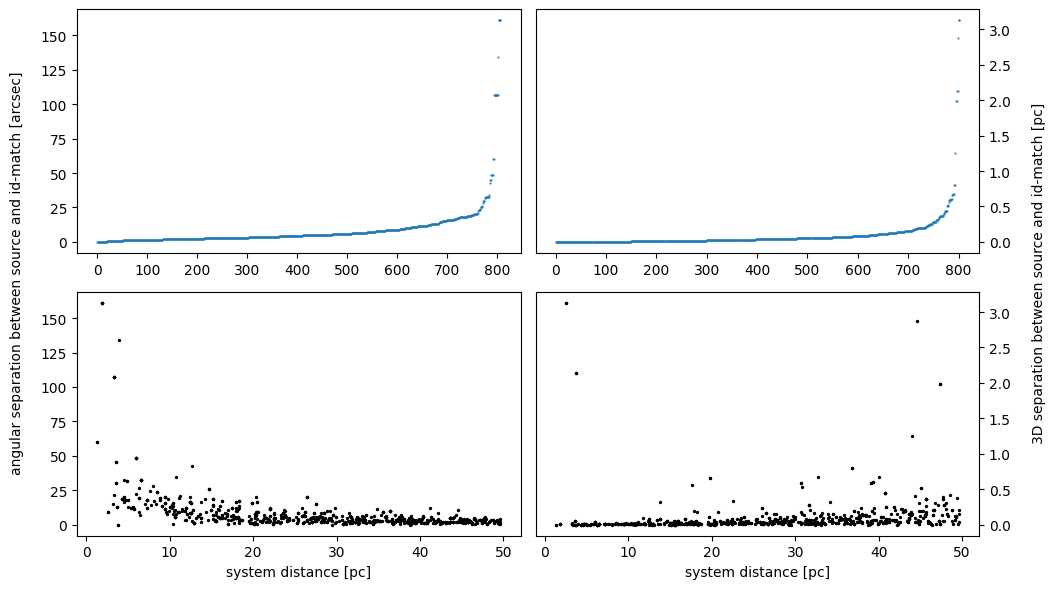

In [ ]:
input_coords = SkyCoord(ra=id_matched["ra_input"]*u.deg, dec=id_matched["dec_input"]*u.deg, distance=id_matched["sy_dist_input"]*u.pc)
output_coords = SkyCoord(ra=id_matched["ra"]*u.deg, dec=id_matched["dec"]*u.deg, distance=id_matched["sy_dist"]*u.pc)


id_matched["min_dist"] = np.fmin(id_matched["sy_dist_input"],id_matched["sy_dist"])

id_matched["sep_2d"] = input_coords.separation(output_coords).to(u.arcsec)
id_matched["proj_3d_angular"] = 206265*u.arcsec*id_matched["sep_3d"]/(id_matched["min_dist"].value*u.pc)

id_matched.sort("min_dist")

fig, ax = plt.subplots(2, 2, figsize=(10,6), sharey='col')

ax[0, 0].plot(np.sort(id_matched["sep_2d"]), ".", ms=1)

ax[1, 0].scatter(id_matched["min_dist"], id_matched["sep_2d"], s=2, color="black")
ax[1, 0].set_xlabel("system distance [pc]")

ax[0, 1].plot(np.sort(id_matched["sep_3d"]), ".", ms=1)
ax[0, 1].yaxis.tick_right()

ax[1, 1].scatter(id_matched["min_dist"], id_matched["sep_3d"], s=2, color="black")
ax[1, 1].set_xlabel("system distance [pc]")
ax[1, 1].yaxis.tick_right()

plt.tight_layout()

# One centered y-label per column, spanning both subplots
for col, label, side in [
    (0, "angular separation between source and id-match [arcsec]", 'left'),
    (1, "3D separation between source and id-match [pc]", 'right'),
]:
    pos_top = ax[0, col].get_position()
    pos_bot = ax[1, col].get_position()
    y_mid = (pos_top.y1 + pos_bot.y0) / 2
    x_label = pos_bot.x0 - 0.06 if side == 'left' else pos_bot.x1 + 0.06
    fig.text(x_label, y_mid, label, ha='center', va='center', rotation='vertical',
             fontsize=plt.rcParams['axes.labelsize'])


In [ ]:
# Scatter plot with point labels for the largest deviations
residual = measured - expected
ranked = np.argsort(np.abs(residual))[::-1]
show_n = min(15, len(ranked))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(expected, measured, s=20, alpha=0.6, color="gray")
ax.scatter(expected[ranked[:show_n]], measured[ranked[:show_n]], s=60, color="crimson")
for i in ranked[:show_n]:
    ax.text(expected[i], measured[i], f"{i}", fontsize=7, color="crimson")

lims = [0, max(np.nanmax(expected), np.nanmax(measured)) * 1.05]
ax.plot(lims, lims, "k--", lw=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Expected separation [arcsec]")
ax.set_ylabel("Measured separation [arcsec]")
ax.set_title("Largest residuals highlighted")
plt.tight_layout()


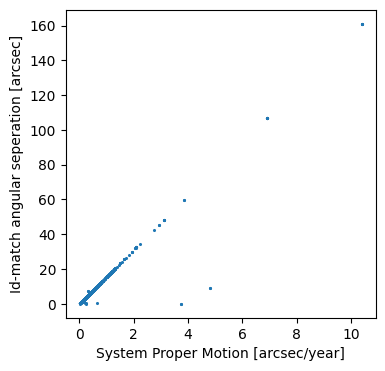

In [ ]:
plt.figure(figsize=(4,4))
plt.scatter(id_matched["sy_pm"]/1000, id_matched["sep_2d"], s=1.5)
plt.xlabel("System Proper Motion [arcsec/year]")
plt.ylabel("Id-match angular separation [arcsec]")

plt.savefig("/tmp/id_angular_sep_vs_proper_motion.svg", bbox_inches="tight", dpi=300)

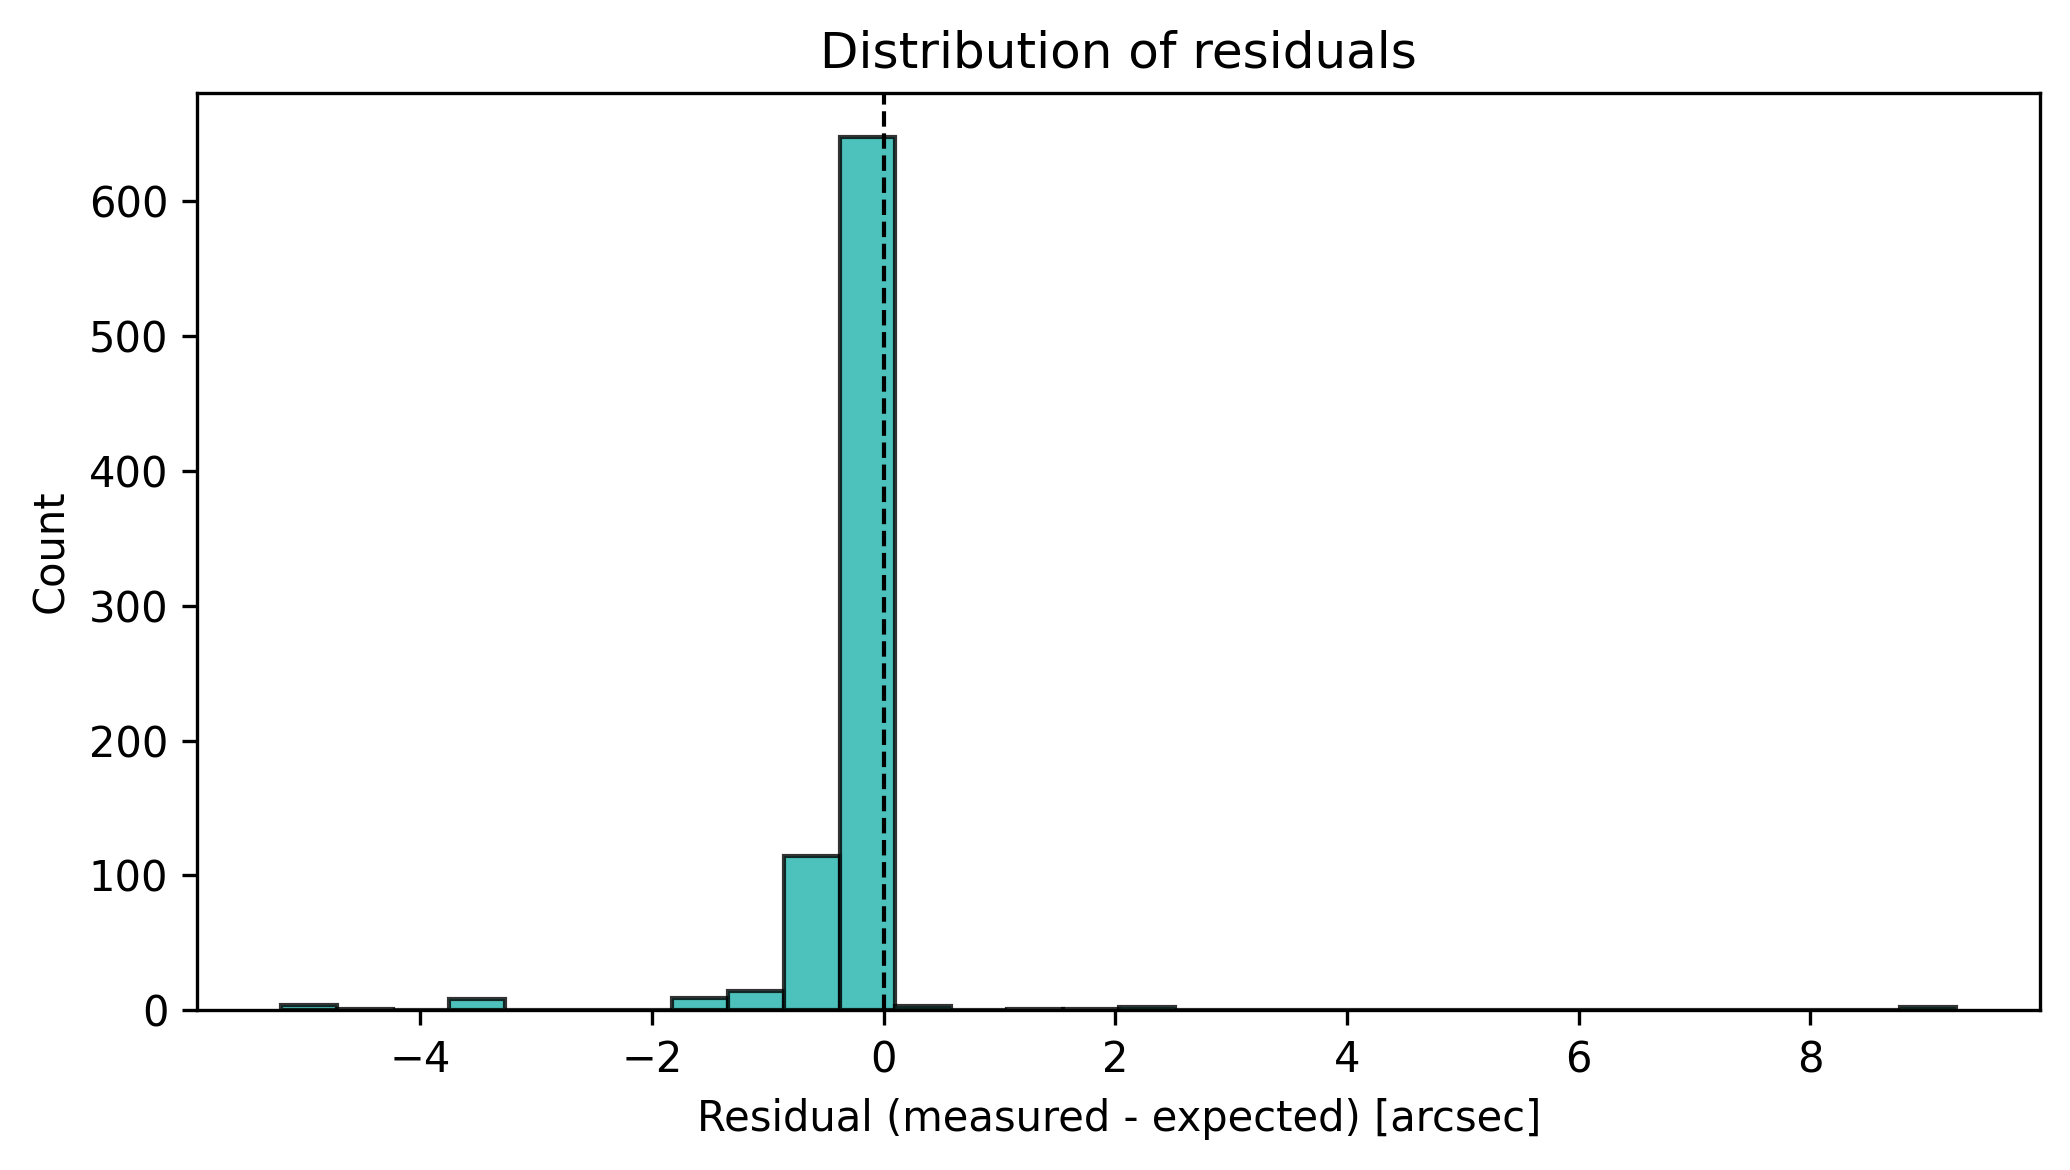

In [ ]:
# Residuals as a histogram to show the distribution of differences
residual = measured - expected
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(residual, bins=30, color="lightseagreen", edgecolor="black", alpha=0.8)
ax.axvline(0, color="black", linestyle="--", lw=1)
ax.set_xlabel("Residual (measured - expected) [arcsec]")
ax.set_ylabel("Count")
ax.set_title("Distribution of residuals")
plt.tight_layout()


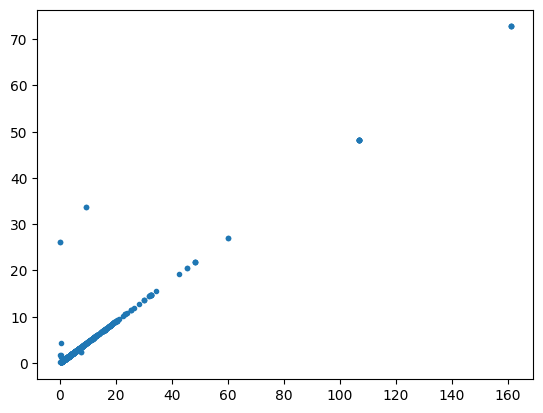

In [ ]:
expected_sep = id_matched["sy_pm"]/1000 * (2026 - 2019)
# ra data
# plt.scatter(id_matched["disc_year"], id_matched["sep_2d"] - expected_sep)
# plt.axhline(np.median(expected_sep))
plt.plot(id_matched["sep_2d"], expected_sep, ".")

In [ ]:
# Bland-Altman style comparison for agreement between expected and measured values
mean_vals = (expected + measured) / 2
diff_vals = measured - expected

fig, ax = plt.subplots(figsize=(8, 4))
ax.axhline(0, color="black", linestyle="--", lw=1)
ax.scatter(mean_vals, diff_vals, s=18, alpha=0.6, color="mediumorchid")
ax.set_xlabel("Mean of expected and measured [arcsec]")
ax.set_ylabel("Difference (measured - expected) [arcsec]")
ax.set_title("Agreement plot")
plt.tight_layout()


In [ ]:
set(id_matched["ra_reflink"])


{np.str_('<a refstr=STASSUN_ET_AL__2019 href=https://ui.adsabs.harvard.edu/abs/2019AJ....158..138S/abstract target=ref>TICv8</a>')}

In [ ]:
ps_comppars = Table.read("pscomppars.txt", format="ascii")
# set(ps_comppars["ra_reflink"])

only_gaia_dr2 = 0
for row in ps_comppars["sy_dist_reflink", "gaia_dr2_id","gaia_dr3_id"].iterrows():
    if not row[2] and row[1]: 
        # print(row)
        only_gaia_dr2 += 1
    # print(row)
# print(only_gaia_dr2)
# print(len(ps_comppars) - np.sum(ps_comppars["sy_dist"] > 0))
ps_comppars[~(ps_comppars["sy_dist"] > 0)]["pl_name", "sy_dist", "sy_dist_reflink"]

pl_name,sy_dist,sy_dist_reflink
str29,float64,str170
SPECULOOS-3 b,--,<a refstr=STASSUN_ET_AL__2019 href=https://ui.adsabs.harvard.edu/abs/2019AJ....158..138S/abstract target=ref>TICv8</a>
Kepler-1984 b,--,<a refstr=STASSUN_ET_AL__2019 href=https://ui.adsabs.harvard.edu/abs/2019AJ....158..138S/abstract target=ref>TICv8</a>
TOI-3540 A b,--,<a refstr=STASSUN_ET_AL__2019 href=https://ui.adsabs.harvard.edu/abs/2019AJ....158..138S/abstract target=ref>TICv8</a>
mu2 Sco b,--,<a refstr=STASSUN_ET_AL__2019 href=https://ui.adsabs.harvard.edu/abs/2019AJ....158..138S/abstract target=ref>TICv8</a>
Kepler-1756 b,--,<a refstr=STASSUN_ET_AL__2019 href=https://ui.adsabs.harvard.edu/abs/2019AJ....158..138S/abstract target=ref>TICv8</a>
V2376 Ori b,--,<a refstr=STASSUN_ET_AL__2019 href=https://ui.adsabs.harvard.edu/abs/2019AJ....158..138S/abstract target=ref>TICv8</a>
Kepler-1795 b,--,<a refstr=STASSUN_ET_AL__2019 href=https://ui.adsabs.harvard.edu/abs/2019AJ....158..138S/abstract target=ref>TICv8</a>
M62H b,--,<a refstr=VLEESCHOWER_ET_AL_2024 href=https://ui.adsabs.harvard.edu/abs/2024MNRAS.530.1436V/abstract target=ref>Vleeschower et al. 2024</a>
TOI-2977 b,--,<a refstr=STASSUN_ET_AL__2019 href=https://ui.adsabs.harvard.edu/abs/2019AJ....158..138S/abstract target=ref>TICv8</a>


In [ ]:
# plt.scatter(id_matched["min_dist"], id_matched["sep_2d"], s=2, color="black")
id_matched.sort("sep_2d",reverse=True)
a = list(id_matched.keys())
a.sort()
for i in a:
    print(i)

WDSsep
ast_flag
cb_flag
dec_cat
dec_input
dec_reflink
dec_solnid
decerr1
decerr2
decstr
decsymerr
disc_facility
disc_instrument
disc_locale
disc_method
disc_pubdate
disc_refid
disc_refname
disc_telescope
disc_year
discoverymethod
dkin_flag
elat
elat_reflink
elat_solnid
elaterr1
elaterr2
elatstr
elatsymerr
elon
elon_reflink
elon_solnid
elonerr1
elonerr2
elonstr
elonsymerr
etv_flag
gaia_binary_fl
gaia_dr2_id
gaia_dr3_id
glat
glat_reflink
glat_solnid
glaterr1
glaterr2
glatstr
glatsymerr
glon
glon_reflink
glon_solnid
glonerr1
glonerr2
glonstr
glonsymerr
hd_name
hip_name
hostid
hostname
htm20
id
ima_flag
input_ids
known_binary_fl
match_type
micro_flag
min_dist
objectid
obm_flag
pl_angsep
pl_angsep_reflink
pl_angseperr1
pl_angseperr2
pl_angsepformat
pl_angseplim
pl_angsepstr
pl_angsepsymerr
pl_bmasse
pl_bmasse_reflink
pl_bmasse_solnid
pl_bmasseerr1
pl_bmasseerr2
pl_bmasseformat
pl_bmasselim
pl_bmassestr
pl_bmassesymerr
pl_bmassj
pl_bmassj_reflink
pl_bmassj_solnid
pl_bmassjerr1
pl_bmassjerr2


In [ ]:
id_matched["ra_reflink"]

<a refstr=STASSUN_ET_AL__2019 href=https://ui.adsabs.harvard.edu/abs/2019AJ....158..138S/abstract target=ref>TICv8</a>
<a refstr=STASSUN_ET_AL__2019 href=https://ui.adsabs.harvard.edu/abs/2019AJ....158..138S/abstract target=ref>TICv8</a>
<a refstr=STASSUN_ET_AL__2019 href=https://ui.adsabs.harvard.edu/abs/2019AJ....158..138S/abstract target=ref>TICv8</a>
<a refstr=STASSUN_ET_AL__2019 href=https://ui.adsabs.harvard.edu/abs/2019AJ....158..138S/abstract target=ref>TICv8</a>
<a refstr=STASSUN_ET_AL__2019 href=https://ui.adsabs.harvard.edu/abs/2019AJ....158..138S/abstract target=ref>TICv8</a>
<a refstr=STASSUN_ET_AL__2019 href=https://ui.adsabs.harvard.edu/abs/2019AJ....158..138S/abstract target=ref>TICv8</a>
<a refstr=STASSUN_ET_AL__2019 href=https://ui.adsabs.harvard.edu/abs/2019AJ....158..138S/abstract target=ref>TICv8</a>
<a refstr=STASSUN_ET_AL__2019 href=https://ui.adsabs.harvard.edu/abs/2019AJ....158..138S/abstract target=ref>TICv8</a>
<a refstr=STASSUN_ET_AL__2019 href=https://ui.adsabs.harvard.edu/abs/2019AJ....158..138S/abstract target=ref>TICv8</a>
<a refstr=STASSUN_ET_AL__2019 href=https://ui.adsabs.harvard.edu/abs/2019AJ....158..138S/abstract target=ref>TICv8</a>
<a refstr=STASSUN_ET_AL__2019 href=https://ui.adsabs.harvard.edu/abs/2019AJ....158..138S/abstract target=ref>TICv8</a>


In [ ]:
id_matched.sort("sep_2d", reverse=True)
id_matched["pl_name", "star_name", "sy_dist_input", "sy_dist_cat", "sy_pm", "sep_2d", "sep_3d", "proj_3d_angular"].show_in_browser()

In [ ]:
id_matched.keys()

['star_name',
 'sy_dist_input',
 'st_spectype_input',
 'st_rad_input',
 'st_teff_input',
 'st_mass_input',
 'st_age_input',
 'ra_input',
 'dec_input',
 'sy_vmag_input',
 'sy_jmag_input',
 'sy_hmag_input',
 'sy_kmag_input',
 'known_binary_fl',
 'gaia_binary_fl',
 'WDSsep',
 'wds_deltamag',
 'objectid',
 'pl_name',
 'pl_letter',
 'hostid',
 'hostname',
 'hd_name',
 'hip_name',
 'tic_id',
 'disc_pubdate',
 'disc_year',
 'disc_method',
 'discoverymethod',
 'disc_locale',
 'disc_facility',
 'disc_instrument',
 'disc_telescope',
 'disc_refname',
 'ra_cat',
 'raerr1',
 'raerr2',
 'rasymerr',
 'rastr',
 'ra_solnid',
 'ra_reflink',
 'dec_cat',
 'decerr1',
 'decerr2',
 'decsymerr',
 'decstr',
 'dec_solnid',
 'dec_reflink',
 'glon',
 'glonerr1',
 'glonerr2',
 'glonsymerr',
 'glonstr',
 'glon_solnid',
 'glon_reflink',
 'glat',
 'glaterr1',
 'glaterr2',
 'glatsymerr',
 'glatstr',
 'glat_solnid',
 'glat_reflink',
 'elon',
 'elonerr1',
 'elonerr2',
 'elonsymerr',
 'elonstr',
 'elon_solnid',
 'elon_re

In [ ]:
set(id_matched["dec_solnid"])


{np.float64(4400.1)}

In [ ]:
id_matched = add_coord_epoch_column(id_matched)

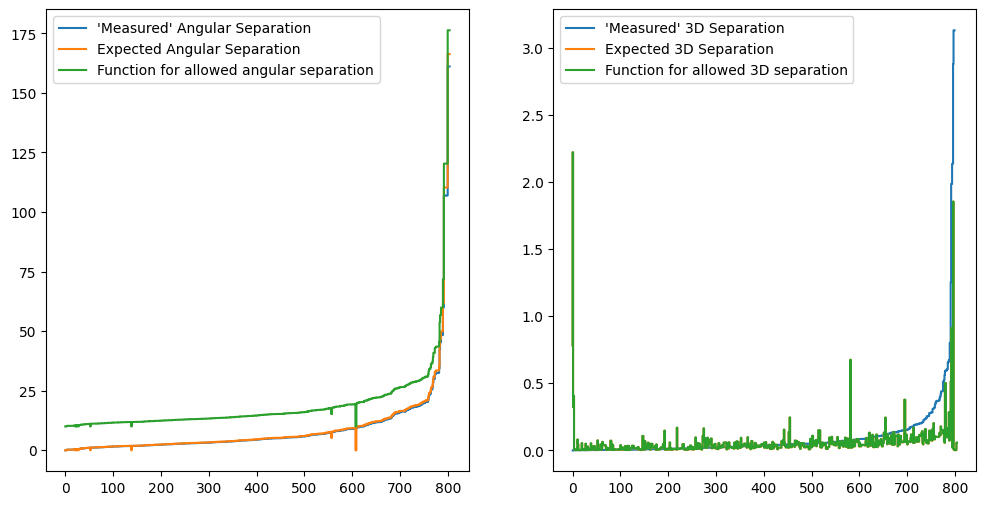

In [ ]:
hpic_epoch = 2000

id_matched["expected_ang_sep"] = allowed_angular_separation(
    id_matched["sy_pm"].filled(0)/1000,
    id_matched["sy_pmerr1"].filled(id_matched["sy_pmerr1"].mean())/1000,
    id_matched["coord_epoch"],
    minimum=0
)
id_matched["allowed_angular_sep"] = allowed_angular_separation(
    id_matched["sy_pm"].filled(0)/1000,
    id_matched["sy_pmerr1"].filled(id_matched["sy_pmerr1"].mean())/1000,
    id_matched["coord_epoch"]
)

id_matched["mean_dist_err"] = (id_matched["sy_disterr1"] - id_matched["sy_disterr2"])/2

id_matched["expected_3d_sep"] = allowed_3d_separation(
    id_matched["allowed_angular_sep"],
    id_matched["st_radv"].filled(0),
    id_matched["min_dist"].filled(0),
    id_matched["mean_dist_err"].filled(id_matched["mean_dist_err"].mean()),
    id_matched["sy_gaiamag"].filled(np.inf),
    id_matched["coord_epoch"],
    minimum=0*u.pc
)

id_matched["allowed_3d_sep"] = allowed_3d_separation(
    id_matched["allowed_angular_sep"],
    id_matched["st_radv"].filled(0),
    id_matched["min_dist"].filled(0),
    id_matched["mean_dist_err"].filled(id_matched["mean_dist_err"].mean()),
    id_matched["sy_gaiamag"].filled(np.inf),
    id_matched["coord_epoch"],
)

x = range(len(id_matched))
fig, axs = plt.subplots(1,2, figsize=(12,6))

id_matched.sort("sep_2d")
axs = axs.flatten()
axs[0].step(x, id_matched["sep_2d"], label="'Measured' Angular Separation")
axs[0].step(x, id_matched["expected_ang_sep"], label="Expected Angular Separation")
axs[0].step(x, id_matched["allowed_angular_sep"], label="Function for allowed angular separation")
axs[0].legend()

id_matched.sort("sep_3d")
axs[1].step(x, id_matched["sep_3d"], label="'Measured' 3D Separation")
axs[1].step(x, id_matched["expected_3d_sep"], label="Expected 3D Separation")
axs[1].step(x, id_matched["allowed_3d_sep"], label="Function for allowed 3D separation")
axs[1].legend()

In [ ]:
id_matched["mean_dist_err"] = (id_matched["sy_disterr1"] - id_matched["sy_disterr2"])/2

id_matched["expected_3d_sep"] = allowed_3d_separation(
    id_matched["allowed_angular_sep"],
    id_matched["st_radv"].filled(0),
    id_matched["min_dist"].filled(0),
    id_matched["mean_dist_err"].filled(id_matched["mean_dist_err"].mean()),
    id_matched["sy_gaiamag"].filled(np.inf),
    id_matched["coord_epoch"],
    minimum=0*u.pc
)

id_matched["allowed_3d_sep"] = allowed_3d_separation(
    id_matched["allowed_angular_sep"],
    id_matched["st_radv"].filled(0),
    id_matched["min_dist"].filled(0),
    id_matched["mean_dist_err"].filled(id_matched["mean_dist_err"].mean()),
    id_matched["sy_gaiamag"].filled(np.inf),
    id_matched["coord_epoch"],
    minimum=0.5*u.pc
) 

import plotly.graph_objects as go

id_matched.sort("sep_3d")
x = list(range(len(id_matched)))
sep_3d       = np.array(id_matched["sep_3d"],          dtype=float)
expected_3d  = np.array(id_matched["expected_3d_sep"], dtype=float)
allowed_3d   = np.array(id_matched["allowed_3d_sep"],  dtype=float)
above_thresh = (allowed_3d > sep_3d).astype(float)
hostnames    = list(id_matched["hostname"])
tic_names    = list(id_matched["star_name"])

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=x, y=above_thresh,
    fill="tozeroy", fillcolor="rgba(0, 180, 0, 0.15)",
    line=dict(color="rgba(0,0,0,0)", shape="hvh"),
    mode="lines", name="Below threshold (success)",
    yaxis="y2",
))
fig.add_trace(go.Scatter(
    x=x, y=sep_3d,
    mode="lines+text",
    name="'Measured' 3D Separation",
    line=dict(shape="hvh"),
    text=hostnames,
    textposition="top center",
    textfont=dict(size=7),
    customdata=list(zip(hostnames, tic_names)),
    hovertemplate="%{customdata[0]}<br>%{customdata[1]}<br>sep: %{y:.5f} pc<extra></extra>",
))
fig.add_trace(go.Scatter(x=x, y=expected_3d, mode="lines", name="Expected 3D Separation",             line=dict(shape="hvh")))
fig.add_trace(go.Scatter(x=x, y=allowed_3d,  mode="lines", name="Function for allowed 3D separation", line=dict(shape="hvh")))
fig.update_layout(
    legend=dict(x=0, y=1),
    yaxis=dict(title="3D Separation [pc]"),
    yaxis2=dict(overlaying="y", range=[0, 1], showticklabels=False, showgrid=False),
    xaxis_title="Star index (sorted by 3D sep)",
    height=500,
)
fig.show()

print(len(above_thresh), above_thresh.sum(), f"{above_thresh.sum()/len(above_thresh)*100:.1f} %")

805 786.0 97.6 %


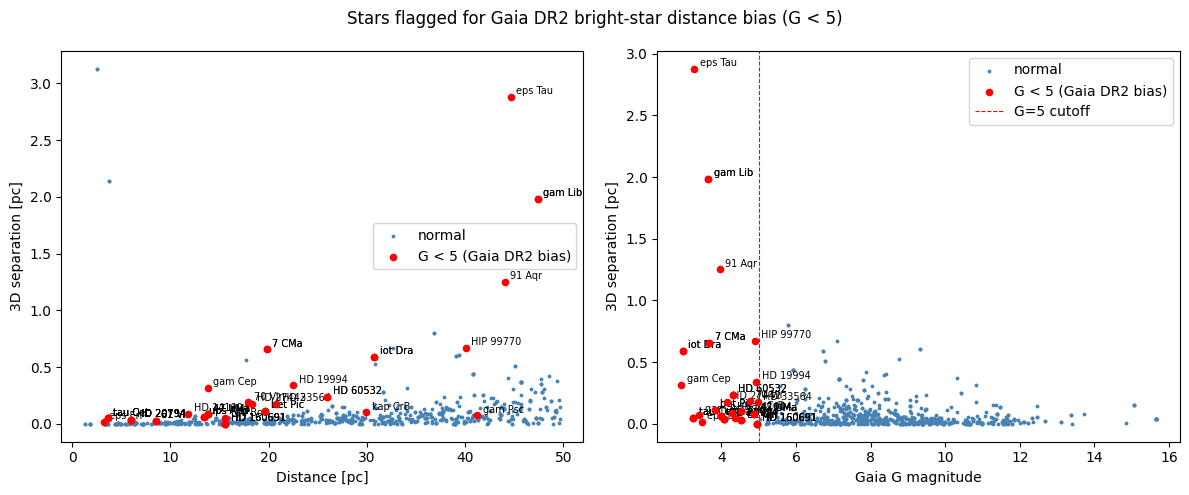

In [ ]:
is_bright = id_matched["sy_gaiamag"].filled(np.inf) < 5

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

for ax, x_col, x_label in [
    (axs[0], "min_dist",   "Distance [pc]"),
    (axs[1], "sy_gaiamag", "Gaia G magnitude"),
]:
    x_all = id_matched[x_col].filled(np.nan)
    ax.scatter(x_all[~is_bright], id_matched["sep_3d"][~is_bright], s=3, color="steelblue", label="normal")
    ax.scatter(x_all[is_bright],  id_matched["sep_3d"][is_bright],  s=20, color="red", zorder=5, label="G < 5 (Gaia DR2 bias)")
    for i in np.where(is_bright)[0]:
        ax.annotate(
            id_matched["hostname"][i],
            (x_all[i], id_matched["sep_3d"][i]),
            fontsize=7, xytext=(4, 2), textcoords="offset points",
        )
    ax.set_xlabel(x_label)
    ax.set_ylabel("3D separation [pc]")
    ax.legend()

axs[1].axvline(5, color="red", linestyle="--", linewidth=0.8, label="G=5 cutoff")
axs[1].legend()
plt.suptitle("Stars flagged for Gaia DR2 bright-star distance bias (G < 5)")
plt.tight_layout()

(array([  9.,  12.,  15.,  36., 142., 186., 124.,  61.,  15.,  13.]),
 array([-121.9 ,  -99.27,  -76.64,  -54.01,  -31.38,   -8.75,   13.88,
          36.51,   59.14,   81.77,  104.4 ]),
 <BarContainer object of 10 artists>)

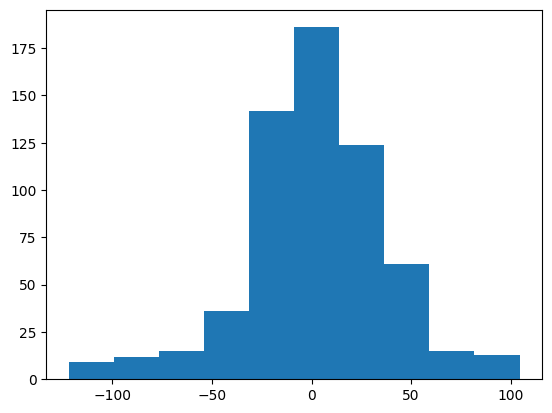

In [ ]:
# plt.plot(np.abs(id_matched["st_radv"])))
plt.hist(id_matched["st_radv"])

In [ ]:
(100 * u.km/u.s).to(u.pc / u.yr) * 20 *u.yr


<Quantity 0.00204542 pc>

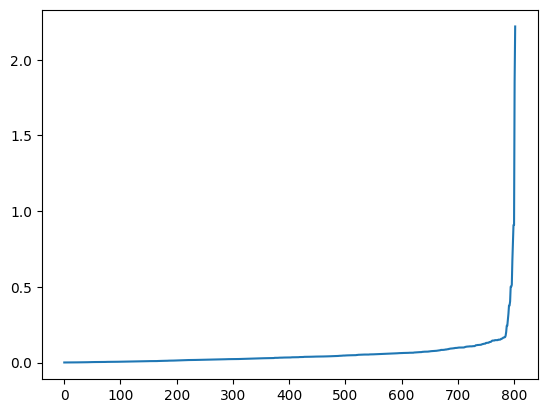

In [ ]:
id_matched["mean_dist_err"] = (id_matched["sy_disterr1"] - id_matched["sy_disterr2"])/2
plt.plot(np.sort(id_matched["mean_dist_err"]))

In [ ]:
for (pm, e), m in zip(id_matched["sy_pm", "coord_epoch"],id_matched["sy_pm"].mask):
    print(pm,e,m)
    # print(allowed_angular_separation(pm/1000, e))

34.4164525 2000.0 False
252.9708712 2000.0 False
199.2234926 2000.0 False
240.4100663 2000.0 False
160.4380043 2016.0 False
1174.0017621 2016.0 False
1174.0017621 2016.0 False
1309.3944652 2016.0 False
1309.3944652 2016.0 False
1365.9371779 2016.0 False
250.2466863 2016.0 False
175.0493765 2016.0 False
113.3529363 2016.0 False
505.070775 2016.0 False
3858.8657674 2016.0 False
3858.8657674 2016.0 False
1706.0088713 2016.0 False
2920.710871 2016.0 False
2920.710871 2016.0 False
580.6759005 2016.0 False
255.0438915 2016.0 False
1225.3257121 2016.0 False
1225.3257121 2016.0 False
1225.3257121 2016.0 False
298.649343 2016.0 False
1187.508409 2016.0 False
1187.508409 2016.0 False
1187.508409 2016.0 False
681.3341342 2016.0 False
833.7162183 2016.0 False
833.7162183 2016.0 False
833.7162183 2016.0 False
302.2287869 2016.0 False
1276.9225263 2016.0 False
703.2913273 2016.0 False
703.2913273 2016.0 False
767.7791462 2016.0 False
767.7791462 2016.0 False
769.8655567 2016.0 False
305.5400786 2016

In [ ]:
id_matched["allowed_angular_sep"] = allowed_angular_separation(
    id_matched["sy_pm"].filled(0)/1000,
    id_matched["sy_pmerr1"].filled(id_matched["sy_pmerr1"].mean())/1000,
    id_matched["coord_epoch"]
)
id_matched["allowed_3d_sep"] = allowed_3d_separation(
    id_matched["allowed_angular_sep"],
    id_matched["st_radv"].filled(0),
    id_matched["min_dist"].filled(0),
    id_matched["mean_dist_err"].filled(id_matched["mean_dist_err"].mean()),
    id_matched["sy_gaiamag"].filled(np.inf),
    id_matched["coord_epoch"],
)

In [ ]:
id_matched["ra_input", "ra_cat"][454]

ra_input,ra_cat
float64,float64
199.19381732782,199.192348


In [ ]:
print((100 * u.arcsec).to(u.rad)*(10*u.pc))
print((0.001/10 * u.rad).to(u.arcsec))

0.0048481368110953596 pc rad
20.626480624709636 arcsec


np.float64(4.6089817888)

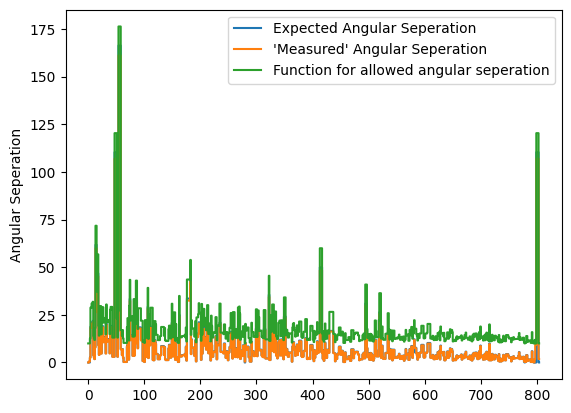

In [ ]:
plt.step(range(len(id_matched)), id_matched["expected_ang_sep"], label="Expected Angular Separation")
plt.step(range(len(id_matched)),id_matched["sep_2d"], label="'Measured' Angular Separation")
plt.step(range(len(id_matched)),id_matched["allowed_angular_sep"], label="Function for allowed angular separation")
plt.ylabel("Angular Separation")
plt.legend()
np.median(id_matched["expected_ang_sep"])

In [ ]:
id_matched[id_matched["star_name"] == "TIC 419015728"]

star_name,sy_dist_input,st_spectype_input,st_rad_input,st_teff_input,st_mass_input,st_age_input,ra_input,dec_input,sy_vmag_input,sy_jmag_input,sy_hmag_input,sy_kmag_input,known_binary_fl,gaia_binary_fl,WDSsep,wds_deltamag,objectid,pl_name,pl_letter,hostid,hostname,hd_name,hip_name,tic_id,disc_pubdate,disc_year,disc_method,discoverymethod,disc_locale,disc_facility,disc_instrument,disc_telescope,disc_refname,ra_cat,raerr1,raerr2,rasymerr,rastr,ra_solnid,ra_reflink,dec_cat,decerr1,decerr2,decsymerr,decstr,dec_solnid,dec_reflink,glon,glonerr1,glonerr2,glonsymerr,glonstr,glon_solnid,glon_reflink,glat,glaterr1,glaterr2,glatsymerr,glatstr,glat_solnid,glat_reflink,elon,elonerr1,elonerr2,elonsymerr,elonstr,elon_solnid,elon_reflink,elat,elaterr1,elaterr2,elatsymerr,elat_solnid,elat_reflink,elatstr,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbpersymerr,pl_orbperlim,pl_orbperstr,pl_orbperformat,pl_orbper_solnid,pl_orbper_reflink,pl_orblpererr1,pl_orblper,pl_orblpererr2,pl_orblpersymerr,pl_orblperlim,pl_orblperstr,pl_orblperformat,pl_orblper_solnid,pl_orblper_reflink,pl_orbsmax,pl_orbsmaxerr1,pl_orbsmaxerr2,pl_orbsmaxsymerr,pl_orbsmaxlim,pl_orbsmaxstr,pl_orbsmaxformat,pl_orbsmax_solnid,pl_orbsmax_reflink,pl_orbincl,pl_orbinclerr1,pl_orbinclerr2,pl_orbinclsymerr,pl_orbincllim,pl_orbinclstr,pl_orbinclformat,pl_orbincl_solnid,pl_orbincl_reflink,pl_orbtper,pl_orbtpererr1,pl_orbtpererr2,pl_orbtpersymerr,pl_orbtperlim,pl_orbtperstr,pl_orbtperformat,pl_orbtper_solnid,pl_orbtper_reflink,pl_orbeccen,pl_orbeccenerr1,pl_orbeccenerr2,pl_orbeccensymerr,pl_orbeccenlim,pl_orbeccenstr,pl_orbeccenformat,pl_orbeccen_solnid,pl_orbeccen_reflink,pl_eqt,pl_eqterr1,pl_eqterr2,pl_eqtsymerr,pl_eqtlim,pl_eqtstr,pl_eqtformat,pl_eqt_solnid,pl_eqt_reflink,pl_occdep,pl_occdeperr1,pl_occdeperr2,pl_occdepsymerr,pl_occdeplim,pl_occdepstr,pl_occdepformat,pl_occdep_solnid,pl_occdep_reflink,pl_insol,pl_insolerr1,pl_insolerr2,pl_insolsymerr,pl_insollim,pl_insolstr,pl_insolformat,pl_insol_solnid,pl_insol_reflink,pl_dens,pl_denserr1,sy_umagerr1,sy_umagerr2,sy_umaglim,sy_umagsymerr,sy_umagstr,sy_umagformat,sy_umag_solnid,sy_umag_reflink,sy_rmag,sy_rmagerr1,sy_rmagerr2,sy_rmaglim,sy_rmagsymerr,sy_rmagstr,sy_rmagformat,sy_rmag_solnid,sy_rmag_reflink,sy_imag,sy_imagerr1,sy_imagerr2,sy_imaglim,sy_imagsymerr,sy_imagstr,sy_imagformat,sy_imag_solnid,sy_imag_reflink,sy_zmag,sy_zmagerr1,sy_zmagerr2,sy_zmaglim,sy_zmagsymerr,sy_zmagstr,sy_zmagformat,sy_zmag_solnid,sy_zmag_reflink,sy_w1mag,sy_w1magerr1,sy_w1magerr2,sy_w1maglim,sy_w1magsymerr,sy_w1magstr,sy_w1magformat,sy_w1mag_solnid,sy_w1mag_reflink,sy_w2mag,sy_w2magerr1,sy_w2magerr2,sy_w2maglim,sy_w2magsymerr,sy_w2magstr,sy_w2magformat,sy_w2mag_solnid,sy_w2mag_reflink,sy_w3mag,sy_w3magerr1,sy_w3magerr2,sy_w3maglim,sy_w3magsymerr,sy_w3magstr,sy_w3magformat,sy_w3mag_solnid,sy_w3mag_reflink,sy_w4mag,sy_w4magerr1,sy_w4magerr2,sy_w4maglim,sy_w4magsymerr,sy_w4magstr,sy_w4magformat,sy_w4mag_solnid,sy_w4mag_reflink,sy_gmag,sy_gmagerr1,sy_gmagerr2,sy_gmaglim,sy_gmagsymerr,sy_gmagstr,sy_gmagformat,sy_gmag_solnid,sy_gmag_reflink,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,sy_gaiamaglim,sy_gaiamagsymerr,sy_gaiamagstr,sy_gaiamagformat,sy_gaiamag_solnid,sy_gaiamag_reflink,sy_tmag,sy_tmagerr1,sy_tmagerr2,sy_tmaglim,sy_tmagsymerr,sy_tmagstr,sy_tmagformat,sy_tmag_solnid,sy_tmag_reflink,sy_name,pl_controv_flag,pl_orbtper_systemref,pl_tranmid_systemref,st_metratio,st_spectype_cat,st_spectype_solnid,st_spectype_reflink,sy_plxlim,sy_kepmag,sy_kepmagerr1,sy_kepmagerr2,sy_kepmaglim,sy_kepmagsymerr,sy_kepmagstr,sy_kepformat,sy_kepmag_solnid,sy_kepmag_reflink,st_rotp,st_rotperr1,st_rotperr2,st_rotpsymerr,st_rotplim,st_rotpstr,st_rotpformat,st_rotp_solnid,st_rotp_reflink,pl_projobliq,pl_projobliqerr1,pl_projobliqerr2,pl_projobliqsymerr,pl_projobliqlim,pl_projobliqstr,pl_projobliqformat,pl_denserr2,pl_denssymerr,pl_denslim,pl_densstr,pl_densformat,pl_dens_solnid,pl_dens_reflink,pl_trandep,pl_trandeperr1,pl_trandeperr2,pl_trandepsymerr,pl_trandeplim,pl_trandepstr,pl_tra

In [ ]:
id_matched.keys()

['star_name',
 'sy_dist_input',
 'st_spectype_input',
 'st_rad_input',
 'st_teff_input',
 'st_mass_input',
 'st_age_input',
 'ra_input',
 'dec_input',
 'sy_vmag_input',
 'sy_jmag_input',
 'sy_hmag_input',
 'sy_kmag_input',
 'known_binary_fl',
 'gaia_binary_fl',
 'WDSsep',
 'wds_deltamag',
 'objectid',
 'pl_name',
 'pl_letter',
 'hostid',
 'hostname',
 'hd_name',
 'hip_name',
 'tic_id',
 'disc_pubdate',
 'disc_year',
 'disc_method',
 'discoverymethod',
 'disc_locale',
 'disc_facility',
 'disc_instrument',
 'disc_telescope',
 'disc_refname',
 'ra_cat',
 'raerr1',
 'raerr2',
 'rasymerr',
 'rastr',
 'ra_solnid',
 'ra_reflink',
 'dec_cat',
 'decerr1',
 'decerr2',
 'decsymerr',
 'decstr',
 'dec_solnid',
 'dec_reflink',
 'glon',
 'glonerr1',
 'glonerr2',
 'glonsymerr',
 'glonstr',
 'glon_solnid',
 'glon_reflink',
 'glat',
 'glaterr1',
 'glaterr2',
 'glatsymerr',
 'glatstr',
 'glat_solnid',
 'glat_reflink',
 'elon',
 'elonerr1',
 'elonerr2',
 'elonsymerr',
 'elonstr',
 'elon_solnid',
 'elon_re

In [ ]:
Counter(cm.catalog_table["sy_dist"].filled(np.nan))

Counter({np.float64(848.254): 8,
         np.float64(12.42988881): 7,
         np.float64(38.9607): 6,
         np.float64(646.346): 6,
         np.float64(282.563): 6,
         np.float64(6800.0): 6,
         np.float64(53.6089): 6,
         np.float64(32.1585): 6,
         np.float64(84.5362): 6,
         np.float64(202.585): 6,
         np.float64(6500.0): 6,
         np.float64(369.451): 6,
         np.float64(46.0907): 6,
         np.float64(6.53127): 6,
         np.float64(106.289): 6,
         np.float64(62.699): 6,
         np.float64(891.092): 5,
         np.float64(6600.0): 5,
         np.float64(64.5978): 5,
         np.float64(7.24396): 5,
         np.float64(578.796): 5,
         np.float64(177.594): 5,
         np.float64(391.038): 5,
         np.float64(323.847): 5,
         np.float64(1027.45): 5,
         np.float64(1209.16): 5,
         np.float64(1798.75): 5,
         np.float64(1056.48): 5,
         np.float64(406.529): 5,
         np.float64(26.7909): 5,
         n